# EDA: build_features 出力検証

対象: 2018年10月（31日分）  
目的: 5年分の本番処理前に、特徴量の出力が正常かを目視確認する

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import mplfinance as mpf

# preprocess.py をインポートできるようにプロジェクトルートをパスに追加
sys.path.insert(0, str(Path('..').resolve()))
from preprocess import load_ticks, build_features

plt.rcParams['figure.figsize'] = (14, 4)
print('imports OK')

imports OK


## ステップ1: 2018年10月を全処理してエラーがないか確認

In [2]:
data_dir = Path('../tmp/2018/10')
files = sorted(data_dir.glob('*.csv'))
print(f'{len(files)} ファイルを処理します')

results = {}
errors = {}
for f in files:
    try:
        ticks = load_ticks(str(f))
        features = build_features(ticks)
        results[f.stem] = features
    except Exception as e:
        errors[f.stem] = str(e)

print(f'成功: {len(results)} / エラー: {len(errors)}')
if errors:
    for k, v in errors.items():
        print(f'  {k}: {v}')

31 ファイルを処理します


成功: 31 / エラー: 0


## ステップ2: ローソク足チャート（最初の3日分）

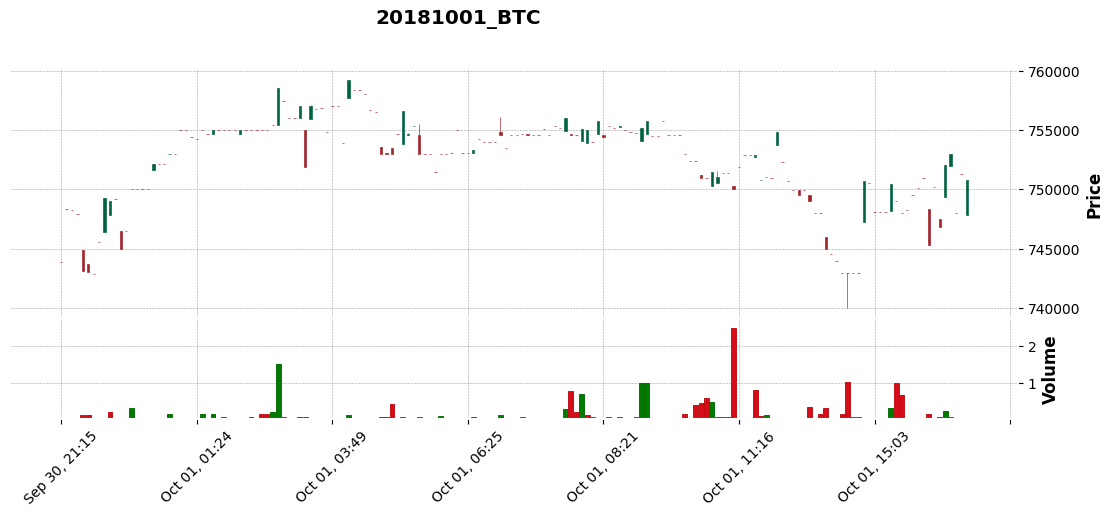

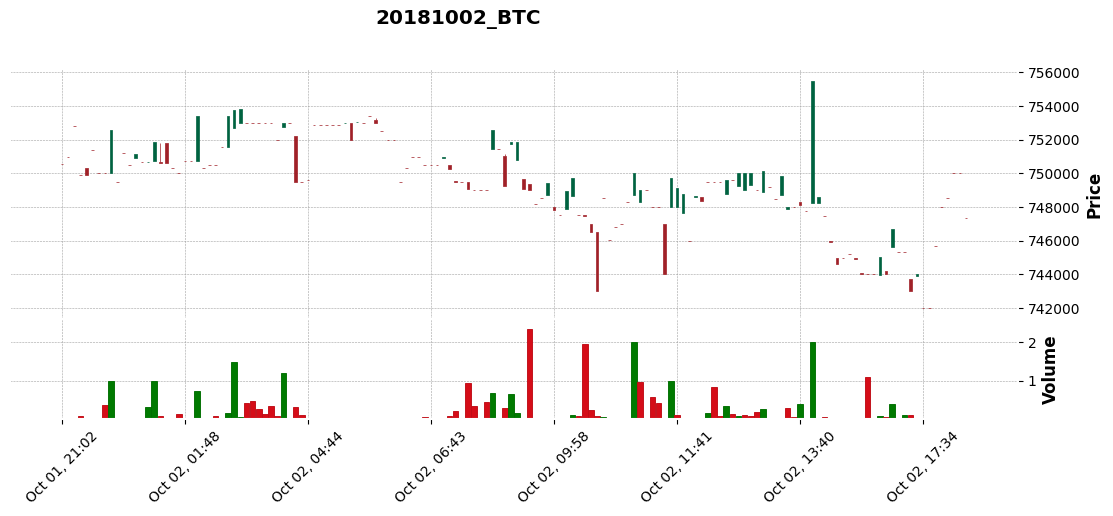

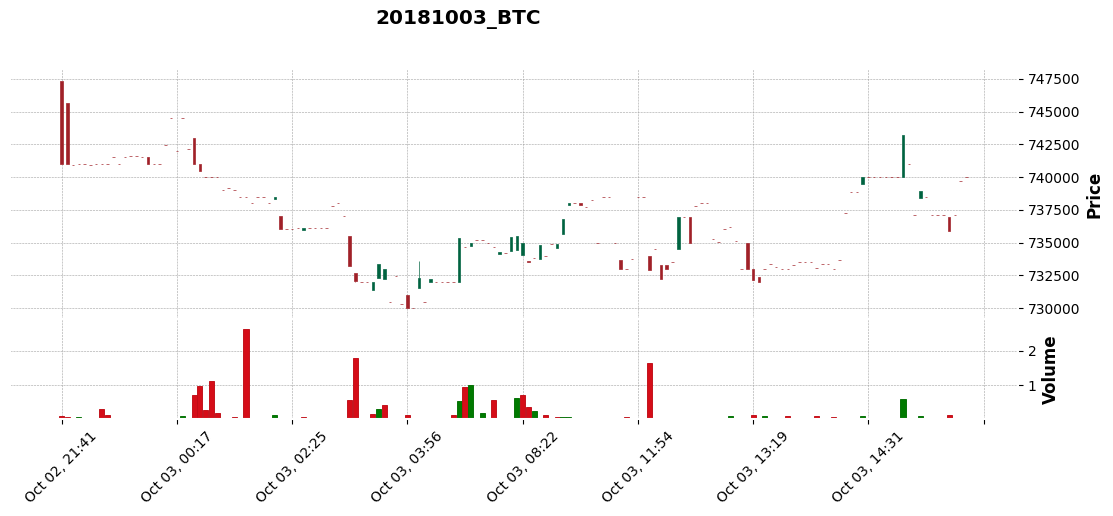

In [3]:
for stem in sorted(results.keys())[:3]:
    df = results[stem].copy()
    df = df.set_index('minute')
    df.index = pd.DatetimeIndex(df.index)
    ohlcv = df[['open', 'high', 'low', 'close', 'volume']].copy()
    ohlcv.columns = ['Open', 'High', 'Low', 'Close', 'Volume']

    fig, axes = mpf.plot(
        ohlcv,
        type='candle',
        volume=True,
        title=stem,
        style='charles',
        returnfig=True,
        figsize=(14, 5),
    )
    plt.show()

## ステップ3: VWAP・Imbalance・Entropy の時系列グラフ（最初の3日分）

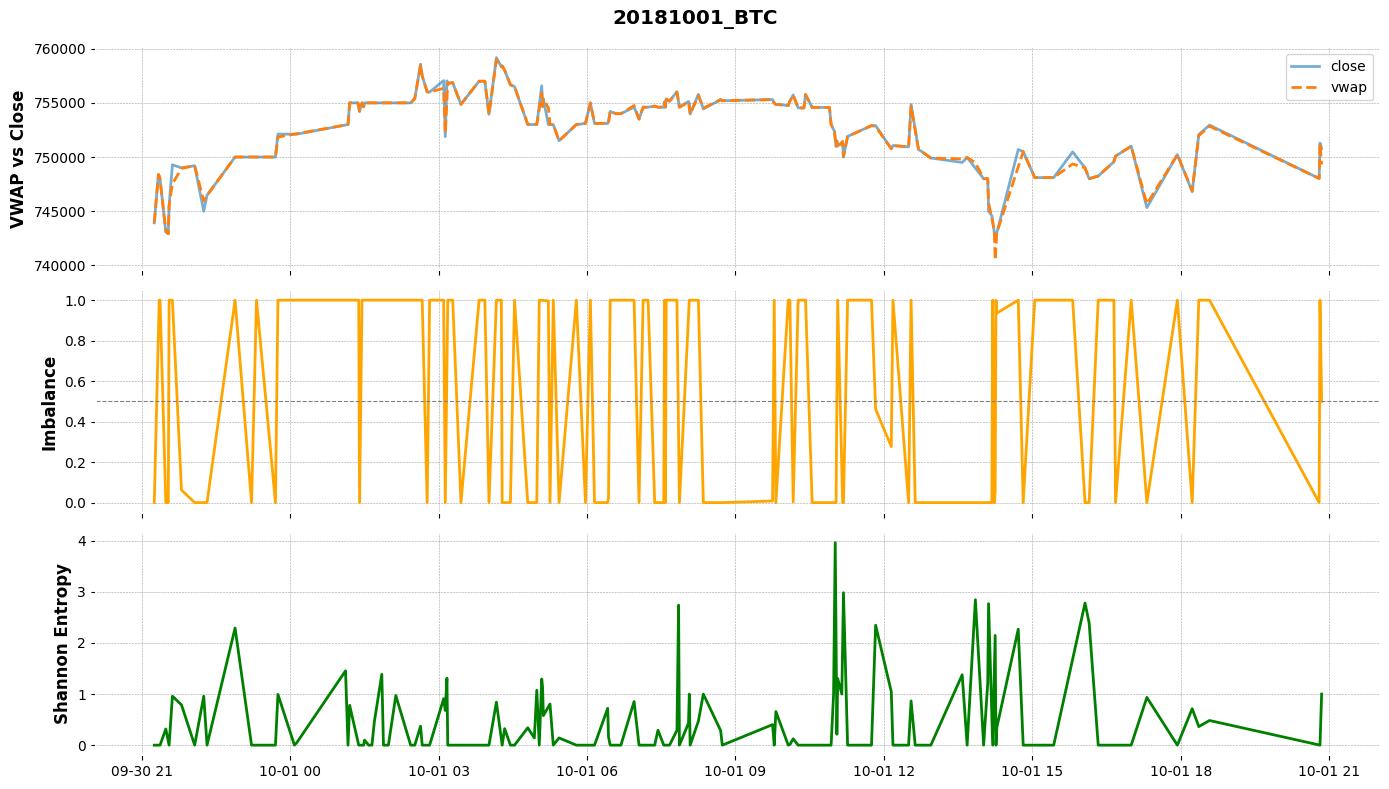

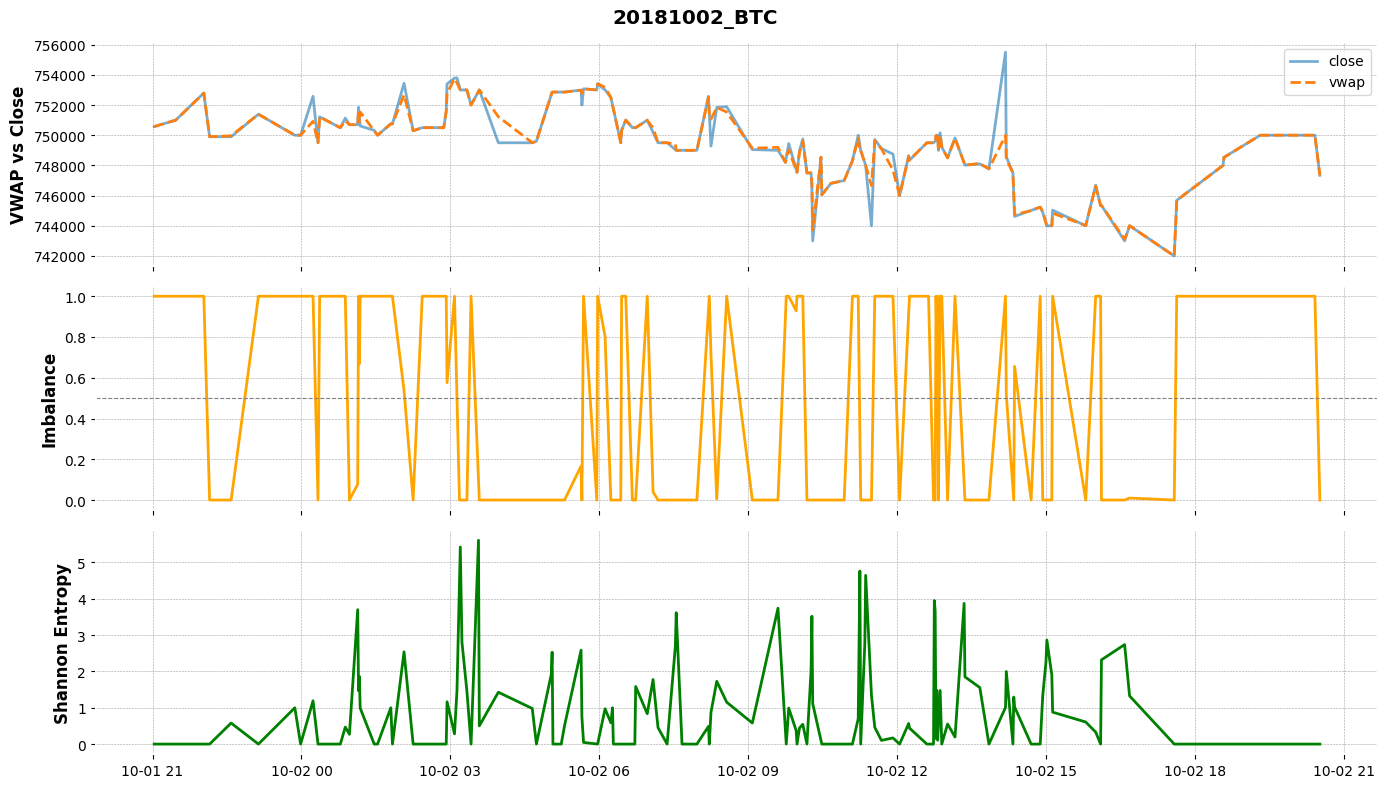

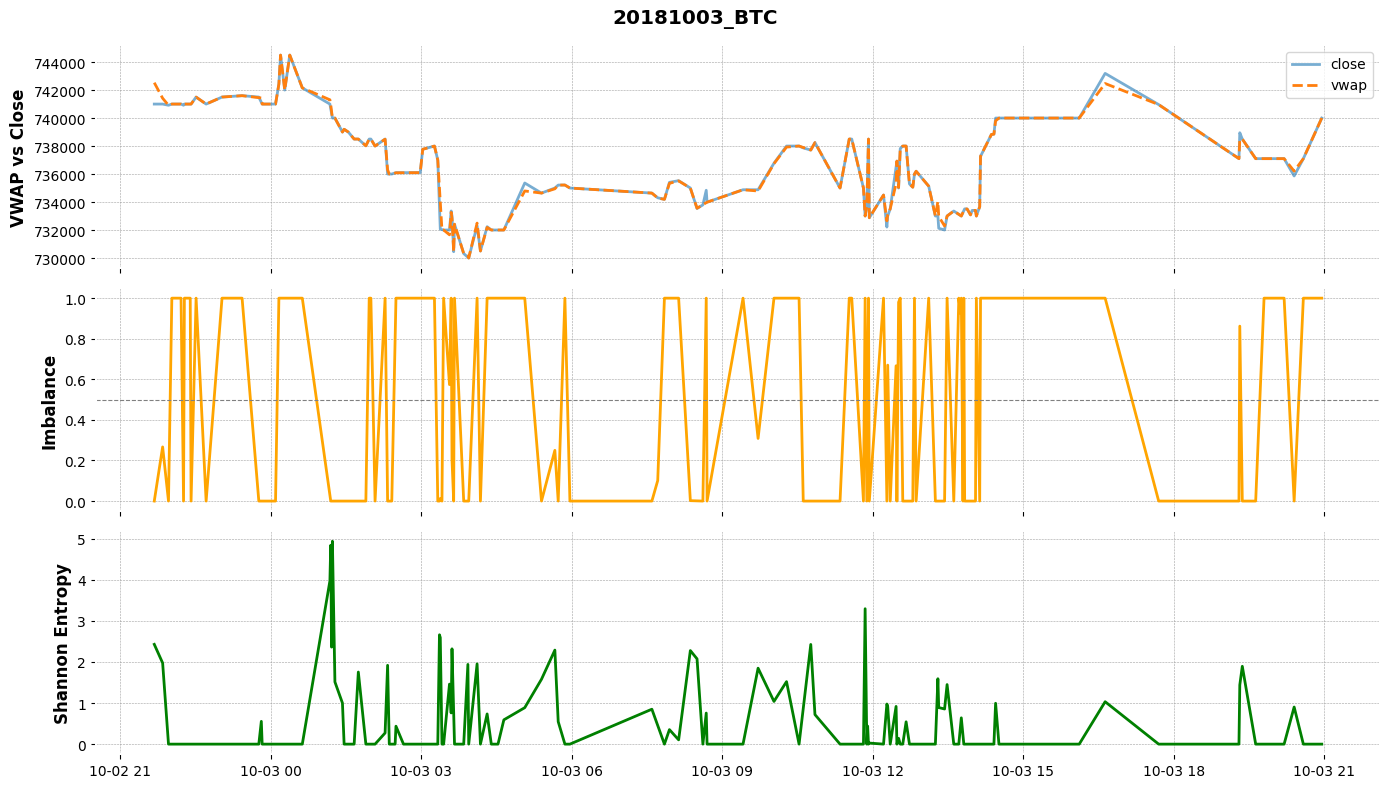

In [4]:
for stem in sorted(results.keys())[:3]:
    df = results[stem].copy()
    df['minute'] = pd.to_datetime(df['minute'])
    df = df.set_index('minute')

    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
    fig.suptitle(stem)

    axes[0].plot(df.index, df['close'], label='close', alpha=0.6)
    axes[0].plot(df.index, df['vwap'], label='vwap', linestyle='--')
    axes[0].set_ylabel('VWAP vs Close')
    axes[0].legend()

    axes[1].plot(df.index, df['imbalance'], color='orange')
    axes[1].axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
    axes[1].set_ylabel('Imbalance')
    axes[1].set_ylim(-0.05, 1.05)

    axes[2].plot(df.index, df['shannon_entropy'], color='green')
    axes[2].set_ylabel('Shannon Entropy')

    plt.tight_layout()
    plt.show()

## ステップ4: 31日分の統計サマリー

In [5]:
rows = []
for stem, df in sorted(results.items()):
    rows.append({
        '日付': stem[:8],
        'バー数': len(df),
        'VWAP欠損': df['vwap'].isna().sum(),
        'Imbalance範囲外': ((df['imbalance'] < 0) | (df['imbalance'] > 1)).sum(),
        'Entropy=0の割合': f"{(df['shannon_entropy'] == 0).mean():.1%}",
        'high<low件数': (df['high'] < df['low']).sum(),
    })

summary = pd.DataFrame(rows)
summary

,日付,バー数,VWAP欠損,Imbalance範囲外,Entropy=0の割合,high<low件数
0,20181001,168,0,0,57.1%,0
1,20181002,148,0,0,41.2%,0
2,20181003,158,0,0,62.7%,0
3,20181004,147,0,0,58.5%,0
4,20181005,113,0,0,51.3%,0
5,20181006,82,0,0,53.7%,0
6,20181007,97,0,0,56.7%,0
7,20181008,113,0,0,61.1%,0
8,20181009,97,0,0,41.2%,0
9,20181010,178,0,0,63.5%,0


/tmp/claude-501/ipykernel_13191/3974872110.py:6: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/claude-501/ipykernel_13191/3974872110.py:6: UserWarning: Glyph 20184 (\N{CJK UNIFIED IDEOGRAPH-4ED8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/claude-501/ipykernel_13191/3974872110.py:6: UserWarning: Glyph 12496 (\N{KATAKANA LETTER BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/claude-501/ipykernel_13191/3974872110.py:6: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/claude-501/ipykernel_13191/3974872110.py:6: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/claude-501/ipykernel_13191/3974872110.py:6: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/claude-501/ipykerne

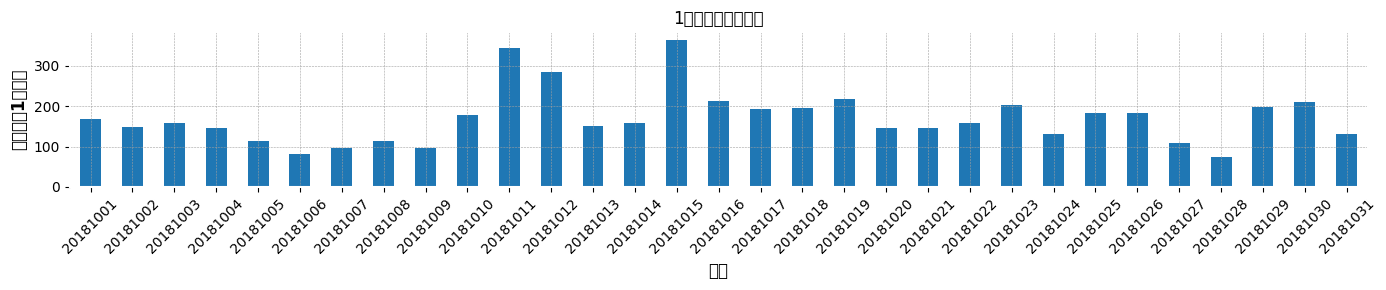

In [6]:
# バー数の日別推移（極端に少ない日がないか確認）
bar_counts = summary.set_index('日付')['バー数']
bar_counts.plot(kind='bar', figsize=(14, 3), title='1日あたりのバー数')
plt.ylabel('バー数（1分足）')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()